# 🎲 Simulación de Montecarlo

## ¿Por qué Montecarlo?
El modelo de costos de la fase anterior calcula la rentabilidad asumiendo valores
fijos para todas las variables. Pero en la realidad argentina, variables como el
precio del combustible, el tipo de cambio o la cantidad de km diarios son inciertas
y fluctúan constantemente.

La **simulación de Montecarlo** resuelve esto: en lugar de calcular una vez con
valores fijos, simula 10.000 escenarios posibles donde cada variable toma un valor
aleatorio dentro de una distribución probabilística realista.

El resultado no es un número único sino una **distribución de probabilidad** que
responde preguntas como:
- ¿Cuál es la probabilidad de que el VW Gol genere más de $800 USD mensuales?
- ¿Qué auto es más resiliente ante una devaluación brusca?
- ¿Cuál es el peor escenario posible para cada modelo?

## Variables inciertas que vamos a simular
| Variable | Distribución | Justificación |
|---|---|---|
| Precio nafta | Normal | Sube gradualmente con volatilidad moderada |
| Precio GNC | Normal | Similar comportamiento al de la nafta |
| Km diarios | Normal | Varía según demanda, clima, zona |
| Tipo de cambio | Normal | Alta volatilidad en Argentina |
| Ingreso bruto | Triangular | Tiene un mínimo, máximo y valor más probable |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")
from src.modelo import PARAMETROS

np.random.seed(42)  # reproducibilidad
N_SIMULACIONES = 10_000

# Parámetros base
p = PARAMETROS

# Definición de distribuciones para cada variable incierta
# Normal(media, desvio_estandar)
distribuciones = {
    "precio_nafta":    {"dist": "normal", "media": p["precio_nafta_ars_litro"],     "std": p["precio_nafta_ars_litro"] * 0.15},
    "precio_gnc":      {"dist": "normal", "media": p["precio_gnc_ars_m3"],          "std": p["precio_gnc_ars_m3"] * 0.15},
    "km_diarios":      {"dist": "normal", "media": p["km_diarios"],                 "std": 20},
    "tipo_cambio":     {"dist": "normal", "media": 1420,                            "std": 150},
    "ingreso_bruto":   {"dist": "triangular", "min": 600_000, "moda": 2_000_000, "max": 2_800_000},
}

print("Distribuciones configuradas:")
for var, config in distribuciones.items():
    print(f"  {var}: {config}")

Distribuciones configuradas:
  precio_nafta: {'dist': 'normal', 'media': 1100, 'std': 165.0}
  precio_gnc: {'dist': 'normal', 'media': 280, 'std': 42.0}
  km_diarios: {'dist': 'normal', 'media': 150, 'std': 20}
  tipo_cambio: {'dist': 'normal', 'media': 1420, 'std': 150}
  ingreso_bruto: {'dist': 'triangular', 'min': 1400000, 'moda': 2000000, 'max': 2800000}


### ¿Por qué estas distribuciones y no otras?

**Normal para precios y km:** la distribución normal es apropiada cuando la variable
fluctúa alrededor de un valor central con igual probabilidad de subir o bajar.
El precio de nafta en Argentina tiene ajustes periódicos pero oscila alrededor
de un valor de referencia — la normal captura eso. Uso un desvío estándar del 15%
que representa escenarios de variación moderada a alta.

**Triangular para ingresos:** a diferencia de la nafta, los ingresos tienen un
piso real (no podés ganar menos de cierto mínimo trabajando 8hs) y un techo
práctico. La distribución triangular es ideal cuando conocés el mínimo, máximo
y valor más probable — exactamente el caso de los ingresos de un chofer.

**`np.random.seed(42)`:** fijar la semilla hace que la simulación sea
reproducible — cualquier persona que corra este notebook va a obtener exactamente
los mismos resultados. Esto es fundamental en ciencia reproducible.

In [2]:
# Datos de los autos
consumo_por_modelo = {
    "Toyota Etios":     8.5,
    "Toyota Corolla":   9.0,
    "Toyota Yaris":     8.0,
    "Chevrolet Prisma": 8.5,
    "Renault Logan":    8.0,
    "Nissan Versa":     9.0,
    "VW Virtus":        8.5,
    "VW Voyage":        9.5,
    "VW Gol":           9.0,
    "Ford Ka":          8.0,
    "Ford Fiesta":      9.0,
    "Fiat Siena":       9.5,
    "Peugeot 208":      7.5,
}

tiene_gnc = {
    "Toyota Etios":     False,
    "Toyota Corolla":   False,
    "Toyota Yaris":     False,
    "Chevrolet Prisma": True,
    "Renault Logan":    True,
    "Nissan Versa":     False,
    "VW Virtus":        False,
    "VW Voyage":        True,
    "VW Gol":           True,
    "Ford Ka":          False,
    "Ford Fiesta":      False,
    "Fiat Siena":       True,
    "Peugeot 208":      False,
}

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

def simular_modelo(precio_compra_usd, consumo_l_100km, gnc, n=N_SIMULACIONES):
    # Samplear variables inciertas
    nafta   = np.random.normal(distribuciones["precio_nafta"]["media"],
                               distribuciones["precio_nafta"]["std"], n)
    gnc_p   = np.random.normal(distribuciones["precio_gnc"]["media"],
                               distribuciones["precio_gnc"]["std"], n)
    km_dia  = np.abs(np.random.normal(distribuciones["km_diarios"]["media"],
                                      distribuciones["km_diarios"]["std"], n))
    tc      = np.abs(np.random.normal(distribuciones["tipo_cambio"]["media"],
                                      distribuciones["tipo_cambio"]["std"], n))
    ingreso = np.random.triangular(distribuciones["ingreso_bruto"]["min"],
                                   distribuciones["ingreso_bruto"]["moda"],
                                   distribuciones["ingreso_bruto"]["max"], n)

    km_mes = km_dia * p["dias_laborales_mes"]

    # Combustible
    if gnc:
        costo_comb = (km_mes / 100) * 10 * gnc_p
    else:
        costo_comb = (km_mes / 100) * consumo_l_100km * nafta

    # Amortización
    precio_ars = precio_compra_usd * tc
    amort = (precio_ars / p["vida_util_km"]) * km_mes

    # Costos fijos
    seguro  = p["seguro_mensual_ars"]
    patente = p["patente_anual_ars"] / 12

    # Ingresos netos Cabify
    ingreso_neto = ingreso * (1 - p["comision_cabify"])

    # Ganancia neta en USD
    ganancia_ars = ingreso_neto - costo_comb - amort - seguro - patente
    ganancia_usd = ganancia_ars / tc

    return ganancia_usd

# Correr simulación para todos los modelos
resultados_mc = {}
for modelo in consumo_por_modelo:
    precio = precio_mediano[modelo]
    resultados_mc[modelo] = simular_modelo(
        precio_compra_usd=precio,
        consumo_l_100km=consumo_por_modelo[modelo],
        gnc=tiene_gnc[modelo]
    )

print(f"Simulación completada: {N_SIMULACIONES:,} escenarios × {len(resultados_mc)} modelos")
print(f"Total de cálculos: {N_SIMULACIONES * len(resultados_mc):,}")

Simulación completada: 10,000 escenarios × 13 modelos
Total de cálculos: 130,000


### Resumen estadístico de la simulación

Para cada modelo extraemos tres percentiles clave:
- **P10 (pesimista):** el 10% de los escenarios son peores que este valor
- **P50 (mediana):** escenario típico
- **P90 (optimista):** el 10% de los escenarios son mejores que este valor

El **P10 es el indicador más importante para la decisión de compra** — te dice
cuánto ganás en el peor escenario probable, no en el ideal.

In [3]:
# Resumen estadístico
resumen = []
for modelo, ganancias in resultados_mc.items():
    resumen.append({
        "modelo": modelo,
        "gnc": tiene_gnc[modelo],
        "p10_usd": np.percentile(ganancias, 10),
        "p50_usd": np.percentile(ganancias, 50),
        "p90_usd": np.percentile(ganancias, 90),
        "media_usd": np.mean(ganancias),
        "std_usd": np.std(ganancias),
        "prob_positivo": np.mean(ganancias > 0) * 100,
    })

df_mc = pd.DataFrame(resumen).set_index("modelo").sort_values("p50_usd", ascending=False)
print(df_mc.round(1).to_string())

                    gnc  p10_usd  p50_usd  p90_usd  media_usd  std_usd  prob_positivo
modelo                                                                               
VW Gol             True    710.9    966.1   1261.1      979.3    214.1          100.0
Fiat Siena         True    691.7    940.9   1247.2      958.8    216.8          100.0
VW Voyage          True    678.8    930.9   1240.0      947.5    217.3          100.0
Chevrolet Prisma   True    653.0    908.7   1221.3      926.2    220.0          100.0
Renault Logan      True    642.0    896.7   1194.3      910.3    214.8          100.0
Ford Fiesta       False    508.2    760.3   1057.3      774.8    214.0          100.0
Ford Ka           False    492.4    741.3   1040.4      756.6    213.5          100.0
Toyota Etios      False    428.3    685.2    984.6      698.2    216.2          100.0
Nissan Versa      False    408.0    667.1    967.5      679.8    217.9          100.0
Peugeot 208       False    392.1    652.8    949.7    

### Visualización de distribuciones

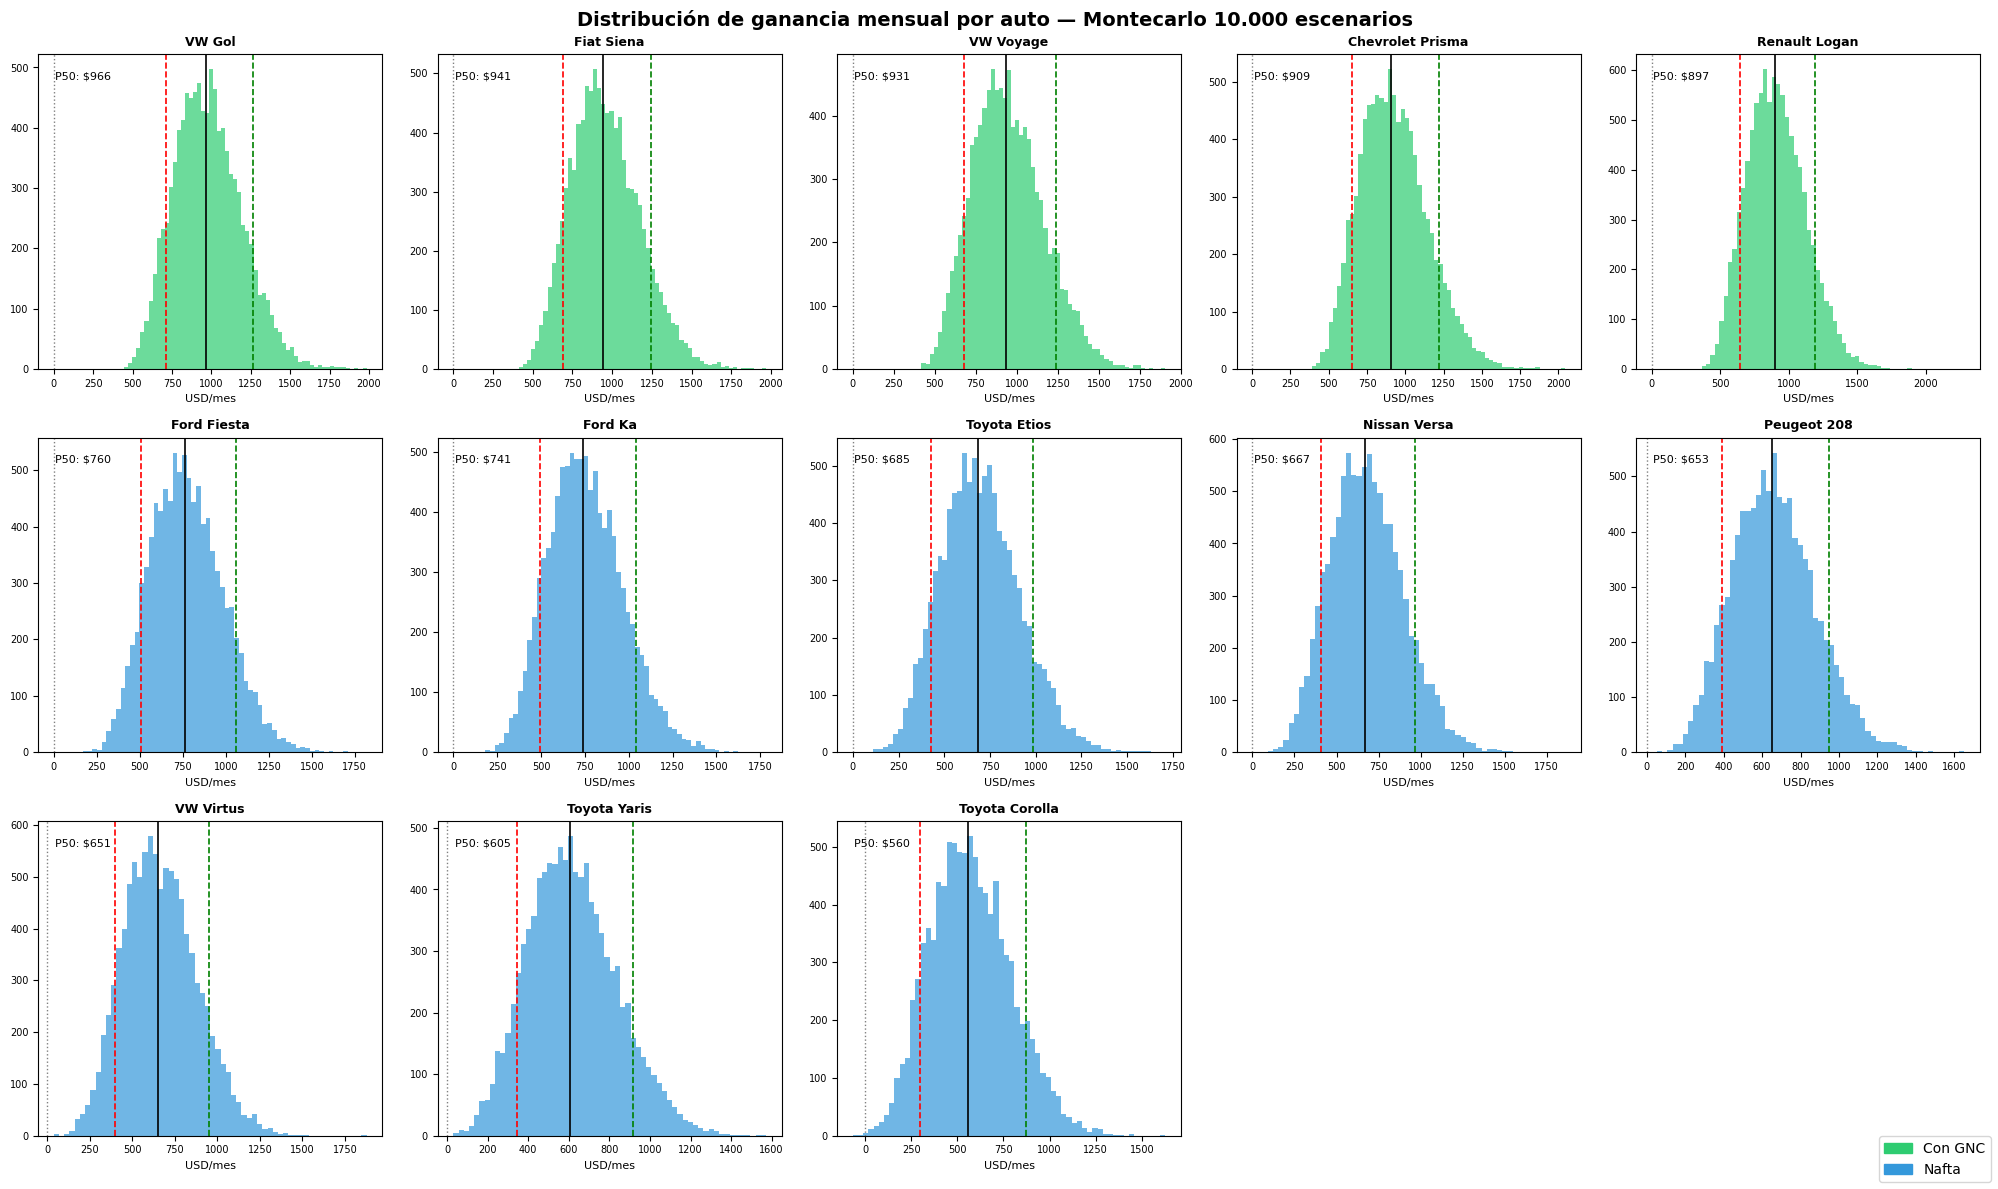

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("Distribución de ganancia mensual por auto — Montecarlo 10.000 escenarios",
             fontsize=14, fontweight="bold")

modelos_orden = df_mc.index.tolist()
axes_flat = axes.flatten()

for i, modelo in enumerate(modelos_orden):
    ax = axes_flat[i]
    ganancias = resultados_mc[modelo]
    color = "#2ecc71" if tiene_gnc[modelo] else "#3498db"

    ax.hist(ganancias, bins=60, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(np.percentile(ganancias, 10),  color="red",    linestyle="--", linewidth=1.2, label="P10")
    ax.axvline(np.percentile(ganancias, 50),  color="black",  linestyle="-",  linewidth=1.2, label="P50")
    ax.axvline(np.percentile(ganancias, 90),  color="green",  linestyle="--", linewidth=1.2, label="P90")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)

    ax.set_title(modelo, fontsize=9, fontweight="bold")
    ax.set_xlabel("USD/mes", fontsize=8)
    ax.tick_params(labelsize=7)

    p50 = np.percentile(ganancias, 50)
    ax.text(0.05, 0.92, f"P50: ${p50:,.0f}", transform=ax.transAxes,
            fontsize=8, color="black")

# Ocultar el subplot extra
axes_flat[-1].set_visible(False)
axes_flat[-2].set_visible(False)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/03_montecarlo_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Comparación de kilometraje entre los modelos GNC líderes

Para validar que la diferencia de rentabilidad entre VW Gol, Fiat Siena y VW Voyage
no se explica por diferencias en el estado del auto, comparé sus kilometrajes medianos:

| Modelo | Km medianos | Precio mediano (USD) | P50 ganancia |
|---|---|---|---|
| VW Voyage | 146.200 km | $8.450 | $931/mes |
| Fiat Siena | 145.000 km | $7.606 | $941/mes |
| VW Gol | 143.000 km | $6.127 | $966/mes |

Los tres tienen kilometrajes casi idénticos — el GNC los iguala en costo de combustible.
La diferencia de rentabilidad se explica **exclusivamente por el precio de entrada**.
El VW Gol gana porque es el más barato, no porque esté en mejor estado.

### Interpretación de la simulación de Montecarlo

Los 5 modelos con GNC dominan el ranking con P50 entre $897 y $966 USD/mes,
muy por encima de los autos a nafta que se agrupan entre $560 y $760 USD/mes.

**Hallazgo clave:** el VW Gol, Fiat Siena y VW Voyage tienen kilometrajes
medianos casi idénticos (~143.000-146.000 km), por lo que su combustible
tiene el mismo costo. La diferencia de rentabilidad entre ellos ($966 vs $931)
se explica casi exclusivamente por el precio de entrada:

| Auto | Precio mediano | P50 ganancia |
|---|---|---|
| VW Gol | $6.127 USD | $966 USD/mes |
| Fiat Siena | $7.606 USD | $941 USD/mes |
| VW Voyage | $8.450 USD | $931 USD/mes |

Esto confirma que en autos con GNC, **el precio de compra es el factor
diferenciador de rentabilidad** — no el combustible, que ya está optimizado.

**Sobre la incertidumbre:** todos los autos a nafta muestran distribuciones
más anchas que los de GNC, lo que indica mayor exposición al riesgo del
precio de la nafta. Los autos GNC son más predecibles en sus ganancias.

### Análisis de sensibilidad — ¿Qué variable impacta más la rentabilidad?

Hasta ahora simulamos todas las variables inciertas juntas. Pero una pregunta
clave es: **¿cuál de todas es la que más afecta la ganancia mensual?**

El **análisis de sensibilidad** responde esto. La metodología es simple:
variamos una variable a la vez (manteniendo el resto fija en su valor base)
y medimos cuánto cambia la ganancia. La variable que genera el mayor cambio
es la más crítica.

El resultado se visualiza en un **tornado chart** — se llama así porque las
barras ordenadas de mayor a menor impacto tienen forma de tornado. Es el
gráfico estándar de análisis de sensibilidad en finanzas y DS.

**¿Por qué importa esto?** Porque le dice al conductor dónde concentrar su
atención. Si el precio de nafta es la variable más crítica, la decisión más
importante es GNC sí o no. Si son los km diarios, la clave es maximizar las
horas trabajadas.

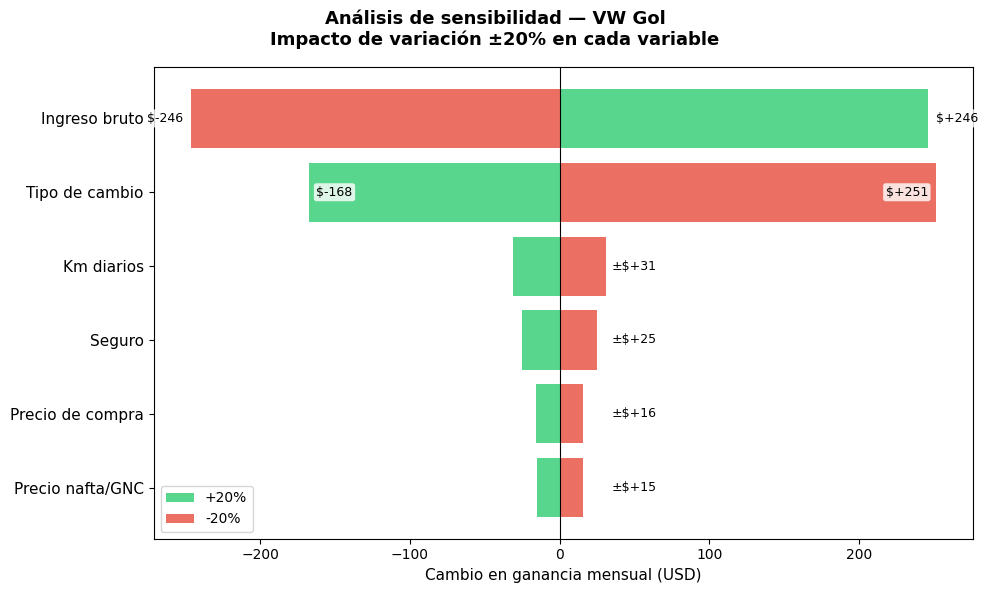

Gráfico guardado.


In [6]:
# Análisis de sensibilidad para el VW Gol (el modelo ganador)
# Variamos cada variable ±20% y medimos el impacto en ganancia

modelo_ref = "VW Gol"
precio_ref = precio_mediano[modelo_ref]
consumo_ref = consumo_por_modelo[modelo_ref]
gnc_ref = tiene_gnc[modelo_ref]
VARIACION = 0.20

variables = {
    "Precio nafta/GNC":   "precio_nafta",
    "Km diarios":         "km_diarios",
    "Tipo de cambio":     "tipo_cambio",
    "Ingreso bruto":      "ingreso_bruto",
    "Precio de compra":   "precio_compra",
    "Seguro":             "seguro",
}

def ganancia_base(precio_compra, km_dia, tc, ingreso, nafta, gnc_precio, gnc):
    km_mes = km_dia * p["dias_laborales_mes"]
    if gnc:
        costo_comb = (km_mes / 100) * 10 * gnc_precio
    else:
        costo_comb = (km_mes / 100) * consumo_ref * nafta
    amort = (precio_compra * tc / p["vida_util_km"]) * km_mes
    ingreso_neto = ingreso * (1 - p["comision_cabify"])
    ganancia_ars = ingreso_neto - costo_comb - amort - p["seguro_mensual_ars"] - p["patente_anual_ars"]/12
    return ganancia_ars / tc

# Valores base
base_args = dict(
    precio_compra=precio_ref,
    km_dia=p["km_diarios"],
    tc=1420,
    ingreso=p["ingreso_bruto_mensual_ars"],
    nafta=p["precio_nafta_ars_litro"],
    gnc_precio=p["precio_gnc_ars_m3"],
    gnc=gnc_ref
)

ganancia_central = ganancia_base(**base_args)

# Calcular impacto de cada variable
sensibilidad = []
variaciones_map = {
    "Precio nafta/GNC": ("nafta", "gnc_precio"),
    "Km diarios":       ("km_dia",),
    "Tipo de cambio":   ("tc",),
    "Ingreso bruto":    ("ingreso",),
    "Precio de compra": ("precio_compra",),
    "Seguro":           ("seguro",),
}

for nombre, keys in variaciones_map.items():
    args_high = base_args.copy()
    args_low  = base_args.copy()

    for k in keys:
        if k == "seguro":
            continue
        args_high[k] = base_args.get(k, p.get("seguro_mensual_ars", 0)) * (1 + VARIACION)
        args_low[k]  = base_args.get(k, p.get("seguro_mensual_ars", 0)) * (1 - VARIACION)

    if nombre == "Seguro":
        args_high_s = base_args.copy()
        args_low_s  = base_args.copy()
        g_high = ganancia_base(**args_high_s) - p["seguro_mensual_ars"] * VARIACION / 1420
        g_low  = ganancia_base(**args_low_s)  + p["seguro_mensual_ars"] * VARIACION / 1420
    else:
        g_high = ganancia_base(**args_high)
        g_low  = ganancia_base(**args_low)

    sensibilidad.append({
        "variable": nombre,
        "impacto_alto": g_high - ganancia_central,
        "impacto_bajo": g_low  - ganancia_central,
        "impacto_total": abs(g_high - ganancia_central) + abs(g_low - ganancia_central)
    })

df_sens = pd.DataFrame(sensibilidad).sort_values("impacto_total", ascending=True)

# Tornado chart
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Análisis de sensibilidad — {modelo_ref}\nImpacto de variación ±20% en cada variable",
             fontsize=13, fontweight="bold")

y_pos = range(len(df_sens))
ax.barh(y_pos, df_sens["impacto_alto"], color="#2ecc71", alpha=0.8, label="+20%")
ax.barh(y_pos, df_sens["impacto_bajo"], color="#e74c3c", alpha=0.8, label="-20%")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sens["variable"], fontsize=11)
ax.set_xlabel("Cambio en ganancia mensual (USD)", fontsize=11)
ax.legend(fontsize=10)

for i, row in enumerate(df_sens.itertuples()):
    impacto_total = abs(row.impacto_alto) + abs(row.impacto_bajo)
    
    if impacto_total > 80:  # barras grandes — label afuera
        ax.text(row.impacto_alto + 5, i, f"${row.impacto_alto:+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
        ax.text(row.impacto_bajo - 5, i, f"${row.impacto_bajo:+.0f}",
                va="center", fontsize=9, color="black", ha="right",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
    else:  # barras chicas — un solo label a la derecha
        ax.text(35, i, f"±${abs(row.impacto_alto):+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))

plt.tight_layout()
plt.savefig("../reports/figures/04_sensibilidad_tornado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del análisis de sensibilidad

El tornado chart revela el orden de impacto de cada variable sobre la rentabilidad
del VW Gol ante una variación del ±20%:

1. **Ingreso bruto (±$246 USD):** la variable de mayor impacto. Esto significa que
   la rentabilidad depende más de cuánto trabajás que de cualquier costo externo.
   Un mes flojo de viajes impacta más que una suba del combustible.

2. **Tipo de cambio (±$168/$251 USD):** segunda variable más crítica y asimétrica —
   una devaluación del peso beneficia al conductor porque sus costos fijos en ARS
   valen menos en dólares, pero su ganancia medida en USD sube. Esto es un efecto
   paradójico típico de la economía argentina.

3. **Km diarios (±$31 USD):** impacto moderado. Más km significa más ingresos pero
   también más combustible y desgaste — los efectos se compensan parcialmente.

4. **Seguro, precio de compra y nafta/GNC (±$15-$25 USD):** impacto marginal.
   Para el VW Gol con GNC, el precio del combustible es prácticamente irrelevante
   — confirma que el GNC elimina el riesgo del precio de la nafta.

**Conclusión clave:** el conductor tiene más poder sobre su rentabilidad
optimizando sus horas de trabajo que preocupándose por los costos del auto.